# Dynamic Predictor Selection for Financial Time Series Using Contextual Multi-Armed Bandits in a Reinforcement Learning Framework

This notebook reproduces the experimental results obtained in the homonimous paper. All the helper functions are collected in the MABSS_utility.py file. You find the data used in the paper in the repository. Big experiments where ran using the cluster provided by the Department of Mathematics at the University of Pisa.  

In [ ]:
CONFIG = dict(
    TICKER = 'SPY',           #time series ticker
    START_DATE = '2000-01-01',  # time series start date

    WINDOW_SIZE = 252,          #walk-forward sliding window size
    MODEL_EMBEDDING = 15,       #input length for MLP
    BANDIT_EMBEDDING = 15,      #context length for CMAB
    EPOCHS = 10,                #train epochs for MLP
    MLP = True,
    RNN = True,
    CNN = True,
    N_SEEDS_PER_ARCH = 20,

    METRIC = 'l1',              #reward metric
    PROB_SCALE = 50.0,              #avg-reward discount
    EPISODES = 100,             #bandit's episodes
    POLICY='ucb',               #bandit's policy

    RANDOM_SEED = 42,
)
CONFIG['N_ARMS'] = CONFIG['N_SEEDS_PER_ARCH'] * sum([CONFIG.get(k, False) for k in ['MLP', 'RNN', 'CNN']])

In [ ]:
# run if needed (for example on a TPU runtime on google colab)
#!pip install yfinance tensorflow statsmodels arch

In [ ]:
import sys
import os
import multiprocessing as mp

notebook_path = '/content/drive/MyDrive/Colab Notebooks/MABSS/'  #your folder
sys.path.append(notebook_path)

from MABSS_utility import *
mp.cpu_count()

2

## Data Preparation

In [ ]:
import json
from pathlib import Path

#adjust to your folder
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster")

loader = ExperimentLoader(CONFIG, BASE_DIR)

if loader.exists("pctchange_preds"):
    print("Data prep cached, loading...")
    pct_change_preds = loader.load("pctchange_preds")
    preds = loader.load("preds")  # optional
else:
    print("Running data prep...")
    ts_close = load_price_series(CONFIG["TICKER"], CONFIG["START_DATE"])
    preds = walk_forward_training(
        ts_close,
        embedding_len=CONFIG["MODEL_EMBEDDING"],
        window_size=CONFIG["WINDOW_SIZE"],
        config=CONFIG,
        epochs=CONFIG["EPOCHS"],
    )
    preds.index = ts_close.iloc[-len(preds):].index

    # 2) Percentage returns
    pct_change_preds = compute_returns_from_preds(preds)
    pct_change_preds['mean'] = pct_change_preds[[f'model_{n}' for n in range(CONFIG['N_ARMS'])]].mean(axis=1)

    loader.save({
        "preds": preds,
        "pctchange_preds": pct_change_preds,
    })

if loader.exists("contexts") and loader.exists("rewards") and loader.exists("rewards_df"):
    print("Rewards and contexts cached, loading...")
    contexts_matrix = loader.load("contexts")
    rewards_matrix = loader.load("rewards")
    rewards_df = loader.load("rewards_df")
else:
    print("Running rewards and context prep...")
    # 3) Rewards + contexts
    rewards_df, contexts_matrix, rewards_matrix = build_rewards_and_contexts(
                                                                          pct_change_preds,
                                                                          metric=CONFIG["METRIC"],
                                                                          bandit_embedding=CONFIG["BANDIT_EMBEDDING"],
                                                                          n_arms=CONFIG["N_ARMS"],
                                                                      )
    loader.save({
        "contexts": contexts_matrix,
        "rewards": rewards_matrix,
        "rewards_df": rewards_df,
    })
# 4) Build X_data / Y_data aligned (with offset = BANDIT_EMBEDDING)
OFFSET = CONFIG["BANDIT_EMBEDDING"]
model_cols = [f"model_{n}" for n in range(CONFIG["N_ARMS"])]
X_data = pct_change_preds[model_cols].values[OFFSET:]
Y_data = pct_change_preds["target"].values[OFFSET:]

if loader.exists("results"):
  print("Bandit results cached, loading...")
  results = loader.load("results")

else:
  print("Running bandit...")
  # 5) Bandit env
  env = WalkForwardEnvCMAB(
      context=contexts_matrix,        # already (T_ctx, d, K)
      X_data=X_data,
      Y_data=Y_data,
      rewards=rewards_matrix,
      config = CONFIG,
      reward_metric=CONFIG["METRIC"],
      k=CONFIG["N_ARMS"],
      d=CONFIG["BANDIT_EMBEDDING"],
      window_size=CONFIG["WINDOW_SIZE"],
      policy_type=CONFIG["POLICY"],
      incremental=False,
      shuffle=True,
      reset=True,
  )

  results = env.run(episodes=CONFIG['EPISODES'])

  loader.save({"results": results})

if loader.exists("multirun_results"):
  print("Multirun results cached, loading...")
  multirun_results = loader.load("multirun_results")
else:
  print("Running multirun bandit...")
  n_seeds = 20
  multirun_results = run_bandit_parallel(
      contexts_matrix=contexts_matrix,
      X_data=X_data,  # aligned with OFFSET
      Y_data=Y_data,
      rewards_matrix=rewards_matrix,
      config=CONFIG,
      n_seeds=n_seeds,
      n_jobs=min(mp.cpu_count(), n_seeds),  # or mp.cpu_count()
  )
  loader.save({"multirun_results": multirun_results})


Data prep cached, loading...
Rewards and contexts cached, loading...
Bandit results cached, loading...
Multirun results cached, loading...


In [ ]:
loader.exists("rewards_df")

True

## Results analysis

### Predictions Analysis

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/CNN-true_EPOCHS-10_MLP-true_MODEL_EMBEDDING-15_N_SEEDS_PER_ARCH-20_RNN-true_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Cumulative return of predictions.png


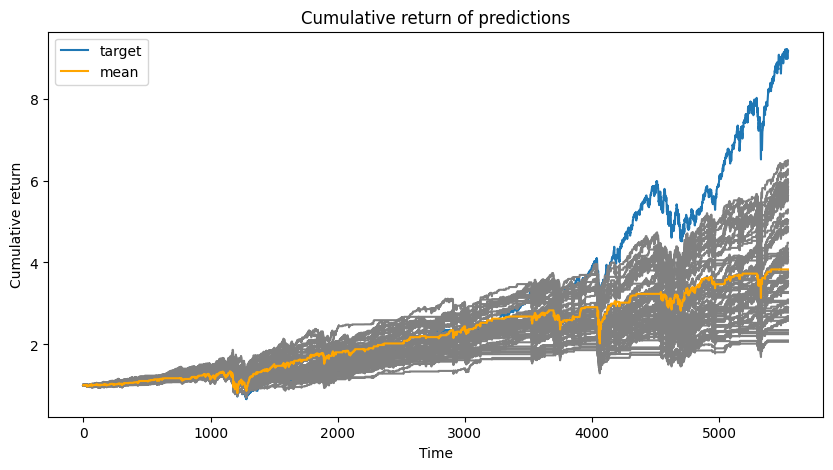

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/CNN-true_EPOCHS-10_MLP-true_MODEL_EMBEDDING-15_N_SEEDS_PER_ARCH-20_RNN-true_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Cumulative return of reward signals.png


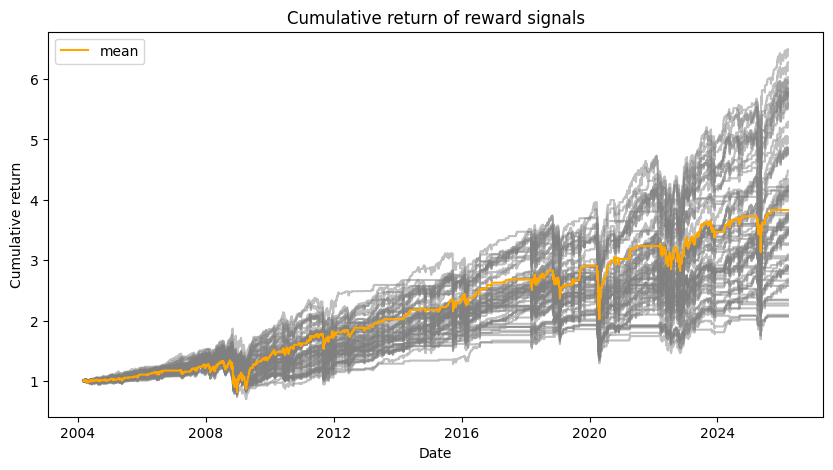

In [ ]:
plot_prediction_analysis(pct_change_preds, save_dir = loader.pred_dir)

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/CNN-true_EPOCHS-10_MLP-true_MODEL_EMBEDDING-15_N_SEEDS_PER_ARCH-20_RNN-true_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/ACF of reward signals.png


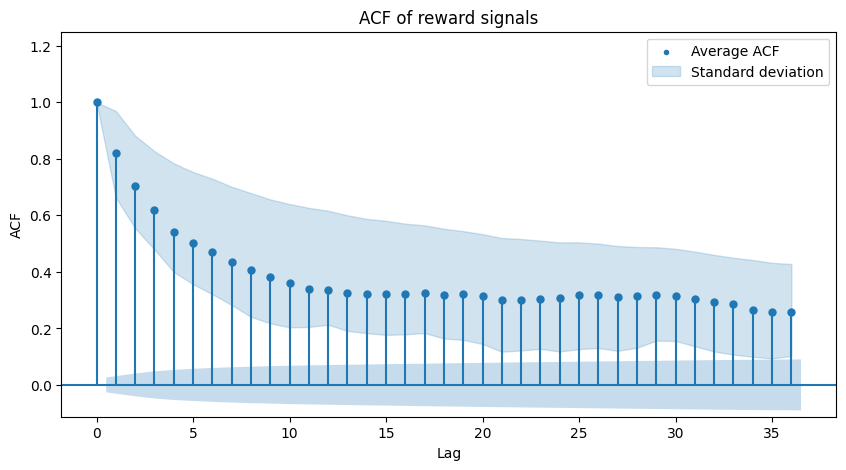

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/CNN-true_EPOCHS-10_MLP-true_MODEL_EMBEDDING-15_N_SEEDS_PER_ARCH-20_RNN-true_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Standard deviation of reward signal across random .png


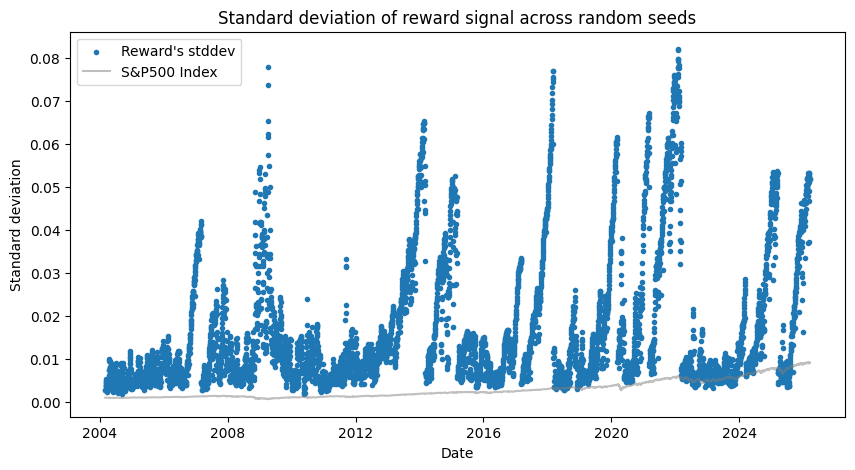

In [ ]:
plot_rewards_stats(rewards_df, pct_change_preds, CONFIG = CONFIG, save_dir = loader.pred_dir)

### Single run bandit analysis

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/BANDIT_EMBEDDING-15_EPISODES-100_METRIC-l1_N_ARMS-60_POLICY-ucb_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Score Softmax agent vs Average - Walk Forward Trai.png


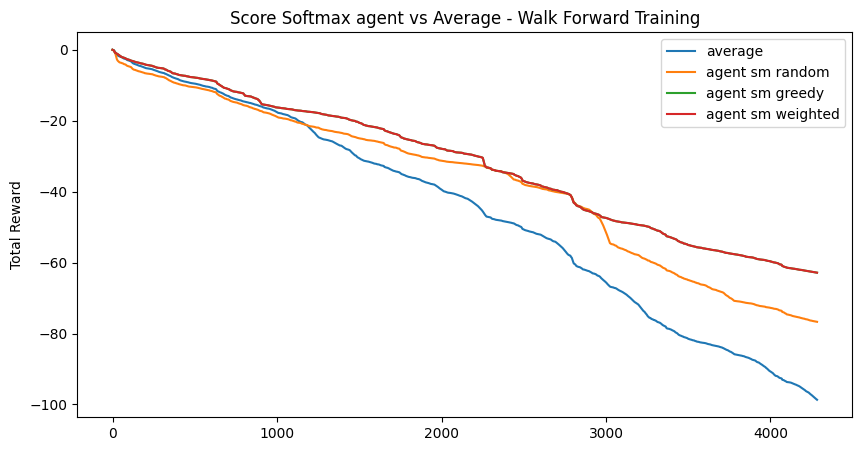

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/BANDIT_EMBEDDING-15_EPISODES-100_METRIC-l1_N_ARMS-60_POLICY-ucb_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Cumulative reward - last 100 steps.png


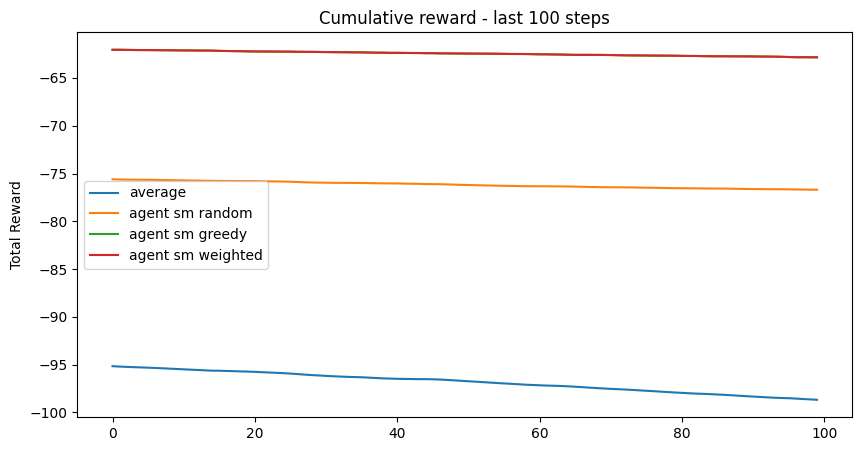

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/BANDIT_EMBEDDING-15_EPISODES-100_METRIC-l1_N_ARMS-60_POLICY-ucb_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Cumulative return of CMAB-derived strategies.png


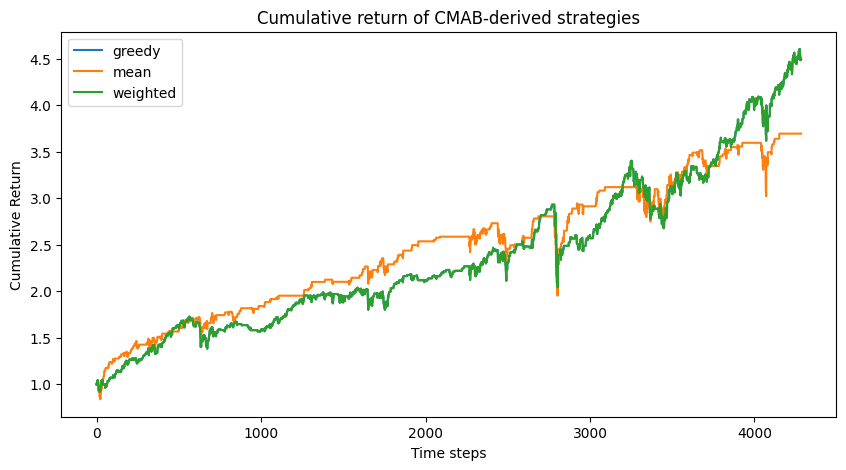

In [ ]:
plot_single_run_bandit(results, pct_change_preds, save_dir = loader.bandit_dir)

### Multi run bandit analysis

In [ ]:
# Access individual results
results_seed0 = multirun_results["seed_0"]
results_all = list(multirun_results.values())


Plotting over horizon T=4284
Best seed: seed_13 (total return: 402.92%)
Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/BANDIT_EMBEDDING-15_EPISODES-100_METRIC-l1_N_ARMS-60_POLICY-ucb_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/CMAB greedy strategy (multi-seed mean ± STD).png


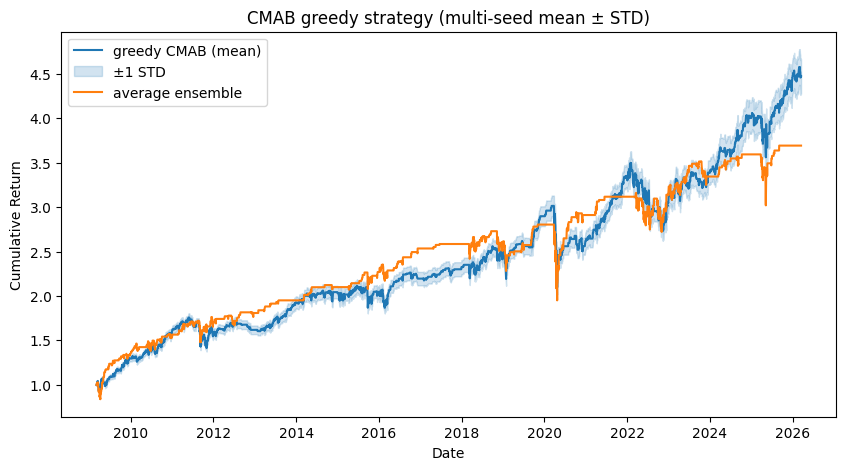

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/BANDIT_EMBEDDING-15_EPISODES-100_METRIC-l1_N_ARMS-60_POLICY-ucb_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/Best seed seed_13_ Cumulative return by arm.png


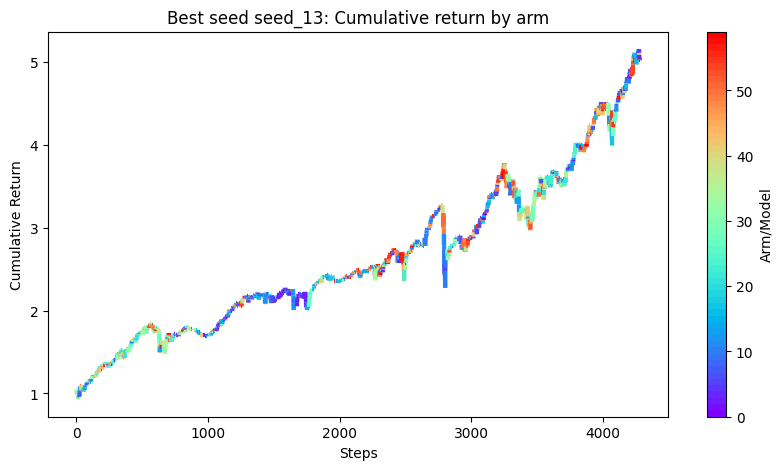

Saved: /content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster/BANDIT_EMBEDDING-15_EPISODES-100_METRIC-l1_N_ARMS-60_POLICY-ucb_START_DATE-2000-01-01_TICKER-SPY_WINDOW_SIZE-252/CMAB vs baselines.png


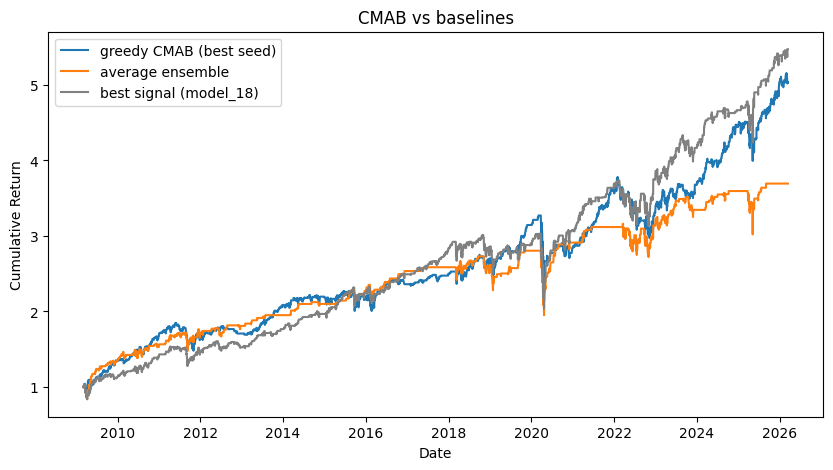

In [ ]:
best_seed, strategies = plot_multi_run_bandit(multirun_results, pct_change_preds, CONFIG, save_dir = loader.bandit_dir)

In [ ]:
# After building strategies in plot_multi_run_bandit (or standalone)
greedy_cols = [c for c in strategies.columns if 'returns_greedy_' in c]
stats = compute_and_highlight_stats(strategies, strategies_greedy_cols=greedy_cols, save_dir = loader.bandit_dir)


,average_ensemble,greedy (mean),greedy (stddev)
total_return,3.215503,3.621426,0.820814
annualized_return,0.088318,0.093301,0.011130
hit_ratio,0.233193,0.222771,0.009185
max_drawdown,-0.301228,-0.286368,0.014285
volatility,0.169036,0.167723,0.002001
sharpe_ratio,0.522481,0.556022,0.063994
calmar_ratio,0.293194,0.327743,0.050402


## Model verification on synthetic data

In [ ]:
import numpy as np
import pandas as pd

def generate_sp500_like_synthetic_prices(
    T=6000,              # number of trading days
    start_price=1000.0,  # starting level
    seed=42
):
    """
    Synthetic price series with S&P500-like drift and volatility
    using a simple GARCH(1,1) volatility process.

    - Annualized volatility ≈ 16%
    - Annualized drift ≈ 8–9%
    - Clear volatility clustering
    - No pathologies (prices stay > 0)
    """
    np.random.seed(seed)

    # --- GARCH(1,1) parameters (typical for equity index daily returns) ---
    alpha = 0.05         # reaction to last squared return
    beta  = 0.90         # persistence of volatility
    omega = 5e-6         # long-run variance level
    mu    = 0.00035      # daily drift ≈ 8–9% annual

    T = int(T)
    sigma2 = np.zeros(T)
    r = np.zeros(T)

    # Start at unconditional variance: var = omega / (1 - alpha - beta)
    sigma2[0] = omega / (1.0 - alpha - beta)

    for t in range(1, T):
        z = np.random.standard_normal()
        # Return = drift + shock * volatility
        r[t] = mu + np.sqrt(sigma2[t-1]) * z
        # GARCH(1,1) variance update
        sigma2[t] = omega + alpha * r[t]**2 + beta * sigma2[t-1]

    # Build price series from returns
    prices = [start_price]
    for x in r:
        prices.append(prices[-1] * (1.0 + x))

    prices_series = pd.Series(prices[1:], name="Close")
    prices_series.index = pd.date_range("2000-01-01", periods=T, freq="B")

    # Diagnostics: drift and volatility
    ann_vol = r.std() * np.sqrt(252)
    ann_ret = (1.0 + r).prod()**(252.0 / len(r)) - 1.0
    max_dd = (prices_series / prices_series.cummax() - 1.0).min()

    print(f"Synthetic S&P500-like series ({T} days)")
    print(f"  Annualized vol   ≈ {ann_vol:.2%}")
    print(f"  Annualized drift ≈ {ann_ret:.2%}")
    print(f"  Final price      = {prices_series.iloc[-1]:.2f}")
    print(f"  Max drawdown     = {max_dd:.2%}")

    return prices_series

# Example usage:
synthetic_prices = generate_sp500_like_synthetic_prices()
# Now feed `synthetic_prices` into your existing `walkforwardtraining` pipeline.



Synthetic S&P500-like series (6000 days)
  Annualized vol   ≈ 15.75%
  Annualized drift ≈ 7.17%
  Final price      = 5196.91
  Max drawdown     = -57.09%


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
synthetic_prices.plot(title='Synthetic EGARCH Prices Over Time', grid=True)
plt.xlabel('Date')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

Running data prep...


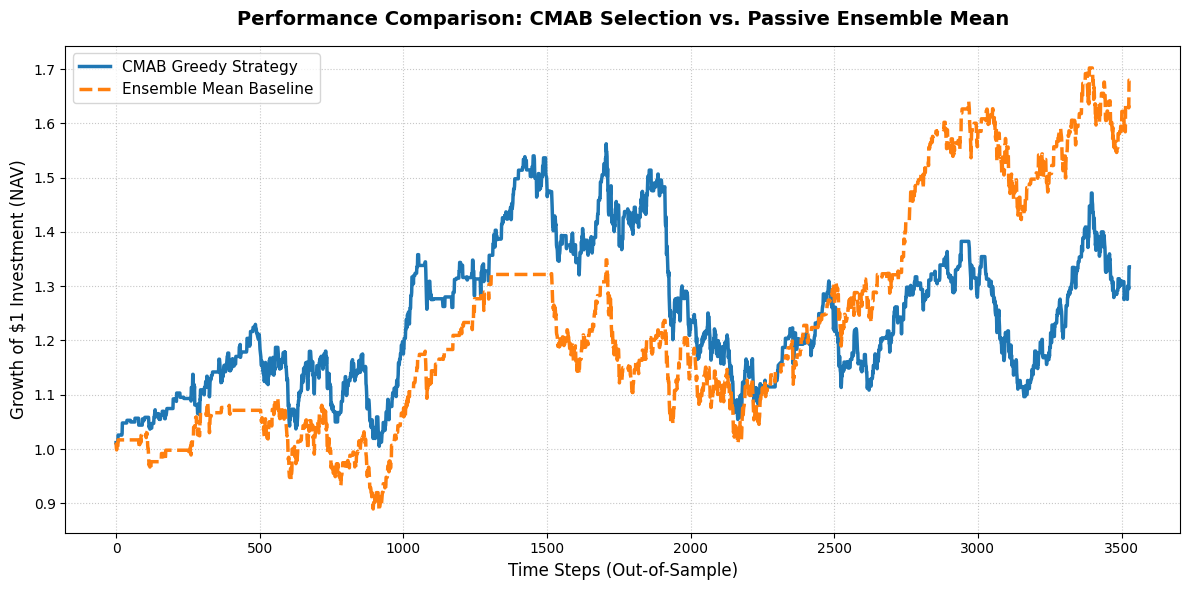

In [ ]:
import json
from pathlib import Path

CONFIG = dict(
    TICKER = 'EGARCH',           #time series ticker
    START_DATE = '2000-01-01',  # time series start date

    WINDOW_SIZE = 252,          #walk-forward sliding window size
    MODEL_EMBEDDING = 15,       #input length for MLP
    BANDIT_EMBEDDING = 15,      #context length for CMAB
    EPOCHS = 10,                #train epochs for MLP
    MLP = True,
    RNN = True,
    CNN = True,
    N_SEEDS_PER_ARCH = 15,
    ALPHA=1,
    GAMMA=None,

    METRIC = 'l1',              #reward metric
    PROB_SCALE = 50.0,              #avg-reward discount
    EPISODES = 75,             #bandit's episodes
    POLICY='ucb',               #bandit's policy

    RANDOM_SEED = 42,
)
CONFIG['N_ARMS'] = CONFIG['N_SEEDS_PER_ARCH'] * sum([CONFIG.get(k, False) for k in ['MLP', 'RNN', 'CNN']])

BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/MABSS/experiments")

loader = ExperimentLoader(CONFIG, BASE_DIR)

print("Running data prep...")
# preds = walk_forward_training(
#   synthetic_prices,
#   embedding_len=CONFIG["MODEL_EMBEDDING"],
#   window_size=CONFIG["WINDOW_SIZE"],
#   config=CONFIG,
#   epochs=CONFIG["EPOCHS"],
# )
results = loader.load("results")
pct_change_preds = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MABSS/experiments/CNN-true_EPOCHS-10_MLP-true_MODEL_EMBEDDING-15_N_SEEDS_PER_ARCH-20_RNN-true_START_DATE-2000-01-01_TICKER-EGARCH_WINDOW_SIZE-252/pctchange_preds.csv')
plot_bandit_strategy_comparison(results,pct_change_preds)

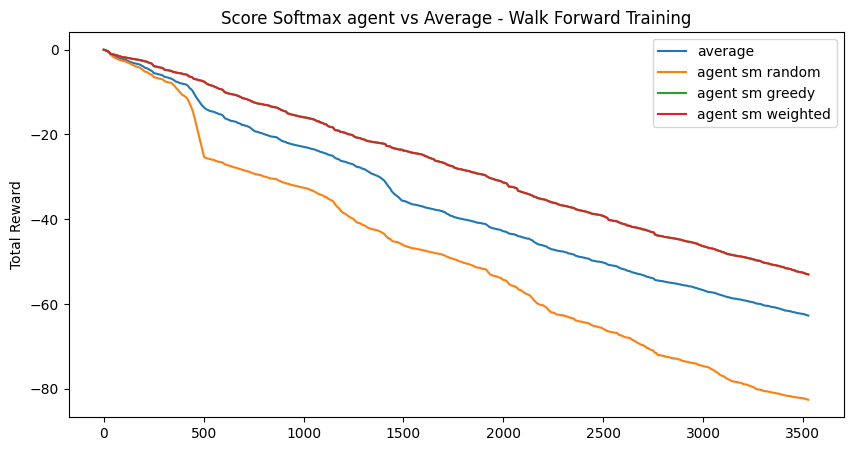

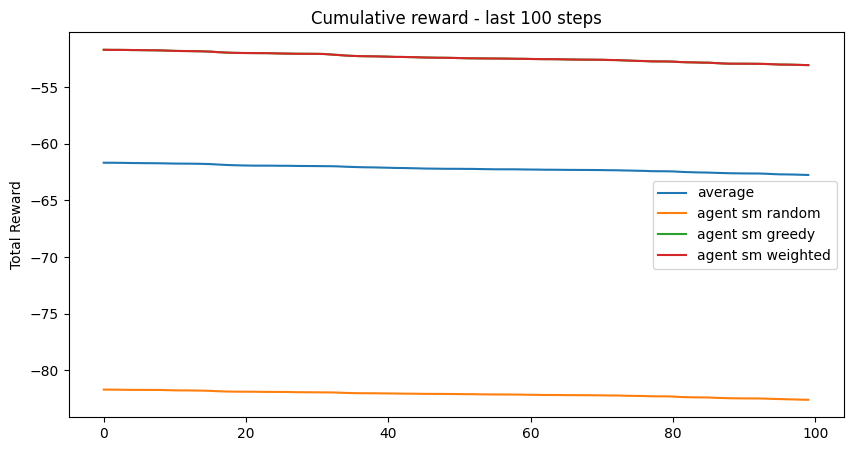

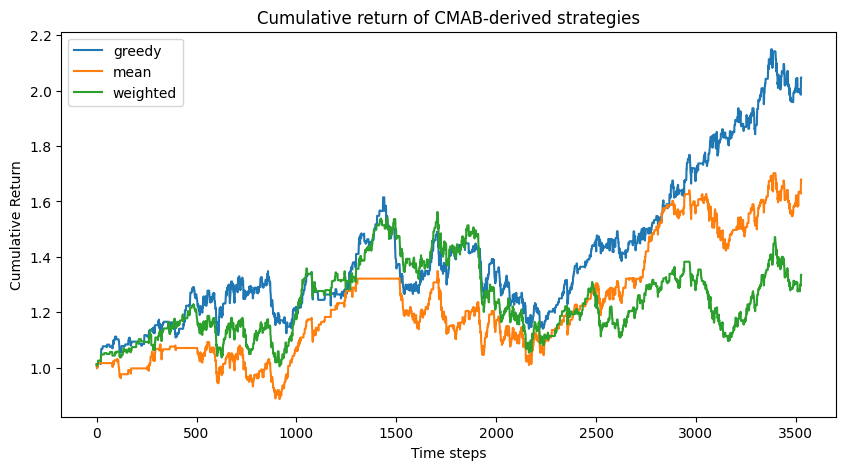

In [ ]:
plot_single_run_bandit(results, pct_change_preds, save_dir = None)

In [ ]:
plot_prediction_analysis(pct_change_preds, save_dir = loader.pred_dir)

## New Plots

### Section 3

In [ ]:
import os
from pathlib import Path

# 1. Configuration
BASE_DIR_CLUSTER = Path("/content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster")
tickers = ['SPY', 'BTC-USD', 'EURUSD=X', 'GC=F']

# Create output directory if it doesn't exist
os.makedirs('./immagini', exist_ok=True)

def load_ticker_data(ticker_name):
    """Helper to load data using the existing ExperimentLoader logic"""
    temp_config = CONFIG.copy()
    temp_config['TICKER'] = ticker_name
    ticker_loader = ExperimentLoader(temp_config, BASE_DIR_CLUSTER)

    r_df = ticker_loader.load("rewards_df") if ticker_loader.exists("rewards_df") else None
    p_preds = ticker_loader.load("pctchange_preds") if ticker_loader.exists("pctchange_preds") else None
    return r_df, p_preds

print("Loading data from experiments_cluster...")

# Load specific dataframes for the next cell
rewards_df_spy, _ = load_ticker_data('SPY')
rewards_df_btc, _ = load_ticker_data('BTC-USD')
rewards_df_eur, _ = load_ticker_data('EURUSD=X')
rewards_df_gcf, _ = load_ticker_data('GC=F')

# Also prepare the representative ticker data (SPY)
_, pct_change_preds_SPY = load_ticker_data('SPY')

print("Data preparation complete for tickers: SPY, BTC, EUR, GC=F.")

Loading data from experiments_cluster...
Data preparation complete for tickers: SPY, BTC, EUR, GC=F.


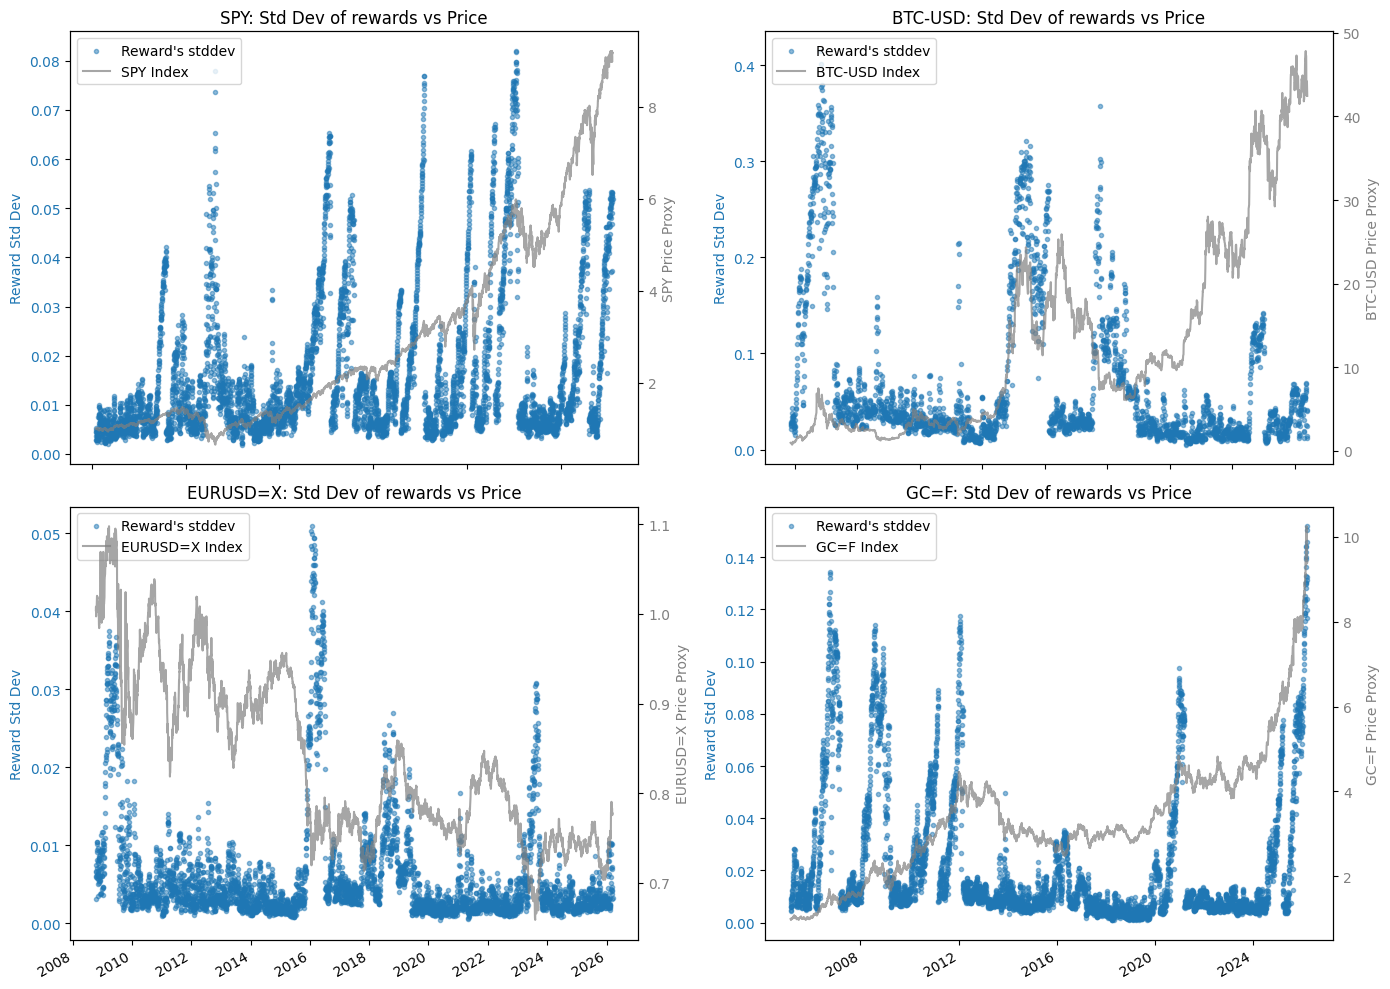

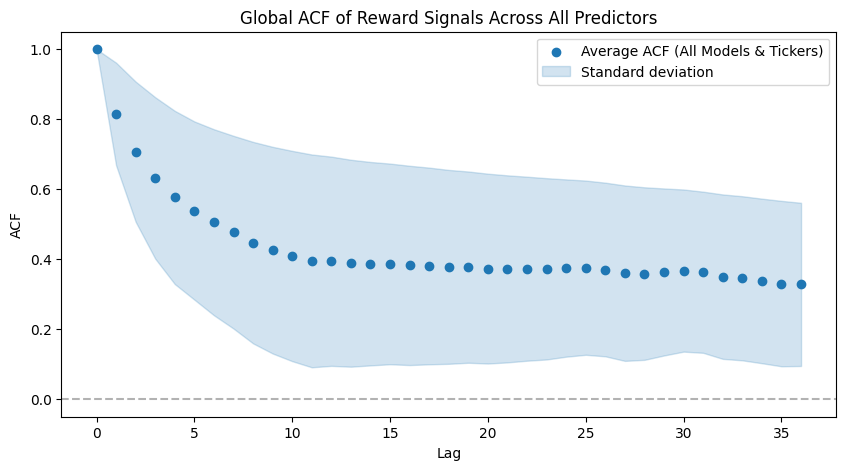

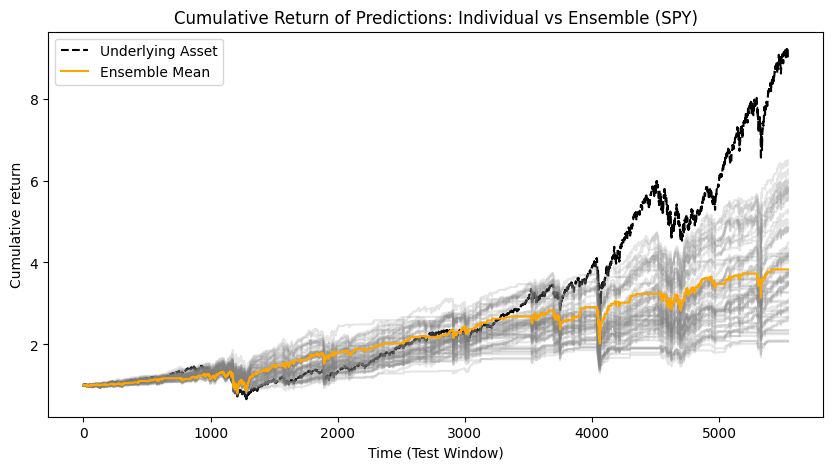

In [ ]:
# 1. Collect your DataFrames from the saved experiments
rewards_dfs_dict = {
    'SPY': rewards_df_spy,
    'BTC-USD': rewards_df_btc,
    'EURUSD=X': rewards_df_eur,
    'GC=F': rewards_df_gcf
}

# 2. Run the Multi-Ticker Grid Plot (Figure 1 in paper)
plot_multiticker_reward_std(rewards_dfs_dict, tickers_to_plot=['SPY', 'BTC-USD', 'EURUSD=X', 'GC=F'], save_dir='./immagini')

# 3. Run the Global ACF Plot (Figure 2 in paper)
plot_global_reward_acf(rewards_dfs_dict, save_dir='./immagini')

# 4. Run the Cumulative Returns Plot for one representative dataset (Figure 3 in paper)
plot_representative_cum_return(pct_change_preds_SPY, ticker='SPY', save_dir='./immagini')

Loading data for variance comparison (SPY)... Homo N_ARMS: 50, Hetero N_ARMS: 60


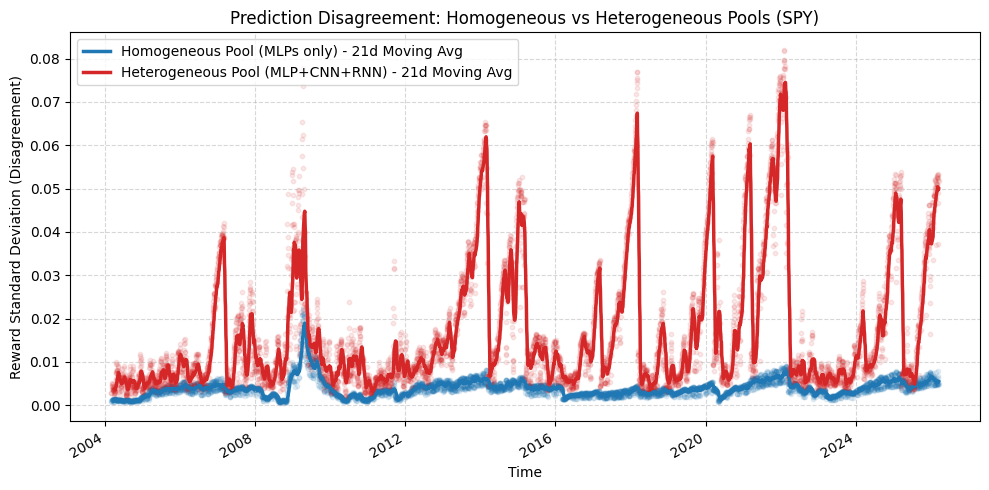

In [ ]:
# 1. Prepare configuration for Homogeneous (MLP only) and Heterogeneous (All) pools
config_homo = CONFIG.copy()
config_homo.update({
    'MLP': True, 'CNN': False, 'RNN': False,
    'TICKER': 'SPY',
    'N_SEEDS_PER_ARCH': 50
})
# Automatically compute N_ARMS for homo
config_homo['N_ARMS'] = config_homo['N_SEEDS_PER_ARCH'] * sum([config_homo.get(k, False) for k in ['MLP', 'RNN', 'CNN']])

config_hetero = CONFIG.copy()
config_hetero.update({
    'MLP': True, 'CNN': True, 'RNN': True,
    'TICKER': 'SPY',
    'N_SEEDS_PER_ARCH': 20
})
# Automatically compute N_ARMS for hetero
config_hetero['N_ARMS'] = config_hetero['N_SEEDS_PER_ARCH'] * sum([config_hetero.get(k, False) for k in ['MLP', 'RNN', 'CNN']])

# 2. Use ExperimentLoader to fetch rewards_df from experiments_cluster
loader_homo = ExperimentLoader(config_homo, BASE_DIR_CLUSTER)
loader_hetero = ExperimentLoader(config_hetero, BASE_DIR_CLUSTER)

print(f"Loading data for variance comparison (SPY)... Homo N_ARMS: {config_homo['N_ARMS']}, Hetero N_ARMS: {config_hetero['N_ARMS']}")
if loader_homo.exists("rewards_df") and loader_hetero.exists("rewards_df"):
    rewards_df_homo = loader_homo.load("rewards_df")
    rewards_df_hetero = loader_hetero.load("rewards_df")

    # 3. Call the plotting function
    plot_variance_comparison(
        rewards_df_homo,
        rewards_df_hetero,
        ticker='SPY',
        window=21,
        save_dir='./immagini'
    )
else:
    print("Error: Cached rewards_df not found for one of the pools in experiments_cluster (SPY).")

### Section 4

In [ ]:
import pandas as pd
import os
from pathlib import Path

# 1. Base Setup
BASE_DIR_CLUSTER = Path("/content/drive/MyDrive/Colab Notebooks/MABSS/experiments_cluster")

base_config = dict(
    START_DATE = '2000-01-01',
    WINDOW_SIZE = 252,
    MODEL_EMBEDDING = 15,
    BANDIT_EMBEDDING = 15,
    EPOCHS = 10,
    METRIC = 'l1',
    PROB_SCALE = 50.0,
    EPISODES = 100,
    RANDOM_SEED = 42,
)

tickers = ['SPY', 'BTC-USD', 'TLT', 'EURUSD=X', 'GC=F']
policies = ['softmax', 'ucb', 'thompson']
archs = [
    {'MLP':True, 'CNN':False, 'RNN':False, 'N_SEEDS_PER_ARCH':50},
    {'MLP':True, 'CNN':True, 'RNN':True, 'N_SEEDS_PER_ARCH':20}
]

all_stats = []

# 2. Iterate and Load
for ticker in tickers:
    for policy in policies:
        for arch in archs:
            # Setup configuration for this specific run
            current_config = base_config.copy()
            current_config.update(arch)
            current_config['TICKER'] = ticker
            current_config['POLICY'] = policy
            current_config['N_ARMS'] = current_config['N_SEEDS_PER_ARCH'] * sum([current_config.get(k, False) for k in ['MLP', 'RNN', 'CNN']])

            loader = ExperimentLoader(current_config, BASE_DIR_CLUSTER)

            # Load stats_df.csv from the bandit directory
            stats_path = Path(loader.bandit_dir) / "stats_df.csv"

            if stats_path.exists():
                # FIXED: Changed index_index to index_col
                df = pd.read_csv(stats_path, index_col=0)

                # Add levels for MultiIndex
                df['Ticker'] = ticker
                df['Policy'] = policy
                df['Arch'] = "Homogeneous" if not arch['CNN'] else "Heterogeneous"

                all_stats.append(df)
            else:
                print(f"Missing stats for: {ticker} | {policy} | {arch['N_SEEDS_PER_ARCH']} seeds")

# 3. Combine into MultiIndex DataFrame
if all_stats:
    combined_stats_df = pd.concat(all_stats)
    combined_stats_df.set_index(['Ticker', 'Policy', 'Arch'], append=True, inplace=True)
    combined_stats_df = combined_stats_df.reorder_levels(['Ticker', 'Policy', 'Arch', combined_stats_df.index.names[0]])
    print("Successfully combined all stats into combined_stats_df.")
    display(combined_stats_df.head())
else:
    print("No stats files found to combine.")

Successfully combined all stats into combined_stats_df.


average_ensemble  greedy (mean)  \
Ticker Policy  Arch                                                             
SPY    softmax Homogeneous total_return               3.350181       3.410779   
                           annualized_return          0.090333       0.090778   
                           hit_ratio                  0.218721       0.191289   
                           max_drawdown              -0.359630      -0.337319   
                           volatility                 0.142054       0.137117   

                                              greedy (stddev)  
Ticker Policy  Arch                                            
SPY    softmax Homogeneous total_return              0.532208  
                           annualized_return         0.007787  
                           hit_ratio                 0.012319  
                           max_drawdown              0.016936  
                           volatility                0.002229

In [ ]:
# Extract only the key metrics we want for the paper
metrics_to_keep = ['annualized_return', 'sharpe_ratio', 'max_drawdown']
df_filtered = combined_stats_df[combined_stats_df.index.get_level_values(3).isin(metrics_to_keep)].copy()

# Reset index to pivot
df_flat = df_filtered.reset_index()
df_flat.rename(columns={'level_3': 'Metric'}, inplace=True) # Rename the metric column

# We want the Ensemble Baseline (which is the same across policies for a given arch/ticker)
# and the Greedy Mean for each policy.
# Let's melt and reconstruct to get 'Method' as a column
records = []
for _, row in df_flat.iterrows():
    # Only add the ensemble baseline once (e.g., when processing the softmax rows)
    if row['Policy'] == 'softmax':
        records.append({
            'Ticker': row['Ticker'], 'Arch': row['Arch'], 'Metric': row['Metric'],
            'Method': 'Ensemble', 'Value': row['average_ensemble']
        })
    # Add the MAB strategy
    records.append({
        'Ticker': row['Ticker'], 'Arch': row['Arch'], 'Metric': row['Metric'],
        'Method': f"MAB ({row['Policy'].upper()})", 'Value': row['greedy (mean)']
    })

final_df = pd.DataFrame(records)

# Pivot into the final table layout
paper_table = final_df.pivot_table(
    index=['Ticker', 'Arch'],
    columns=['Metric', 'Method'],
    values='Value'
)

# Reorder columns for readability
paper_table = paper_table.reindex(columns=metrics_to_keep, level=0)
paper_table = paper_table.reindex(columns=['Ensemble', 'MAB (SOFTMAX)', 'MAB (UCB)', 'MAB (THOMPSON)'], level=1)

# Print the LaTeX code!
print(paper_table.to_latex(float_format="%.2f", multirow=True, multicolumn=True))

\begin{tabular}{llrrrrrrrrrrrr}
\toprule
 & Metric & \multicolumn{4}{r}{annualized_return} & \multicolumn{4}{r}{sharpe_ratio} & \multicolumn{4}{r}{max_drawdown} \\
 & Method & Ensemble & MAB (SOFTMAX) & MAB (UCB) & MAB (THOMPSON) & Ensemble & MAB (SOFTMAX) & MAB (UCB) & MAB (THOMPSON) & Ensemble & MAB (SOFTMAX) & MAB (UCB) & MAB (THOMPSON) \\
Ticker & Arch &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{BTC-USD} & Heterogeneous & 0.05 & 0.19 & 0.29 & 0.15 & 0.16 & 0.48 & 0.80 & 0.39 & -0.67 & -0.55 & -0.60 & -0.72 \\
 & Homogeneous & 0.07 & 0.15 & 0.30 & 0.25 & 0.19 & 0.40 & 0.81 & 0.69 & -0.50 & -0.53 & -0.47 & -0.56 \\
\cline{1-14}
\multirow[t]{2}{*}{EURUSD=X} & Heterogeneous & 0.01 & 0.00 & 0.01 & 0.00 & 0.09 & 0.08 & 0.16 & 0.07 & -0.18 & -0.20 & -0.19 & -0.20 \\
 & Homogeneous & -0.01 & 0.00 & -0.00 & -0.00 & -0.16 & 0.08 & -0.03 & -0.08 & -0.26 & -0.21 & -0.21 & -0.25 \\
\cline{1-14}
\multirow[t]{2}{*}{GC=F} & Heterogeneous & 0.03 & 0.03 & 0.07 & 0.07 & 0.24 & 

Saved figure to ./immagini/multi_run_grid_plot1.png


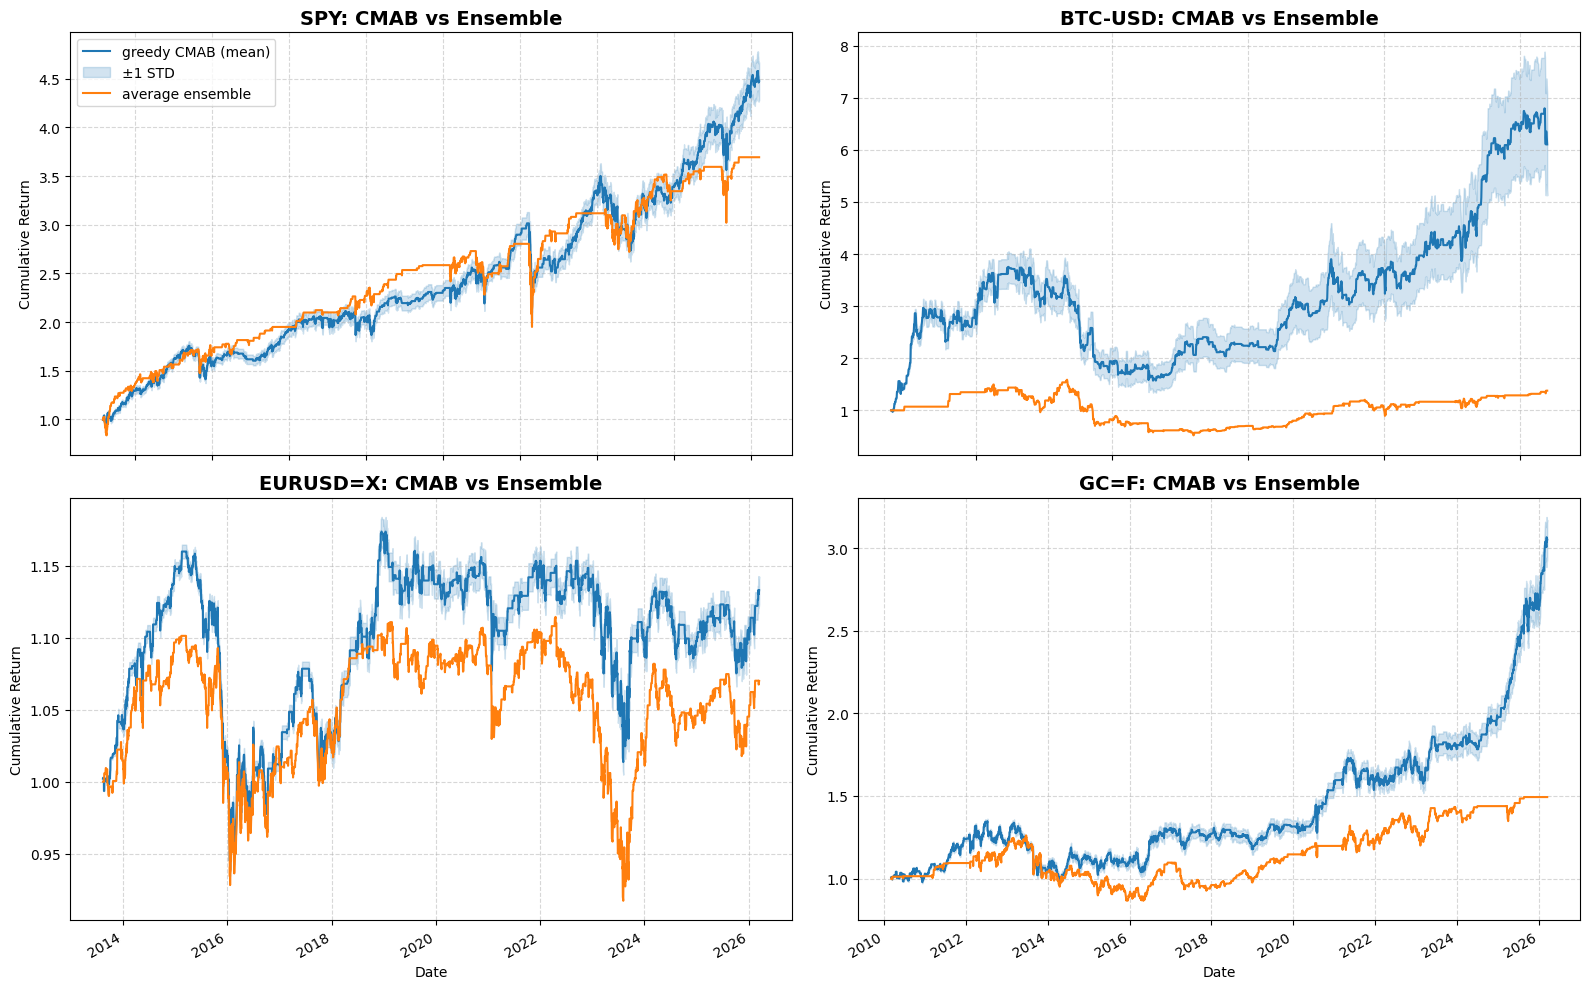

In [ ]:
# Assuming you want to plot the UCB policy for the Heterogeneous architecture
target_policy = 'ucb'
target_arch = {'MLP':True, 'CNN':True, 'RNN':True, 'N_SEEDS_PER_ARCH':20}

ticker_data_dict = {}
grid_tickers = ['SPY', 'BTC-USD', 'EURUSD=X', 'GC=F']

for ticker in grid_tickers:
    # Set up config
    curr_config = base_config.copy()
    curr_config.update(target_arch)
    curr_config['TICKER'] = ticker
    curr_config['POLICY'] = target_policy
    curr_config['N_ARMS'] = curr_config['N_SEEDS_PER_ARCH'] * sum([curr_config.get(k, False) for k in ['MLP', 'RNN', 'CNN']])

    # Load data
    loader = ExperimentLoader(curr_config, BASE_DIR_CLUSTER)

    if loader.exists("multirun_results") and loader.exists("pctchange_preds"):
        results_multi = loader.load("multirun_results")
        pct_preds = loader.load("pctchange_preds")
        ticker_data_dict[ticker] = (results_multi, pct_preds)
    else:
        print(f"Data missing for {ticker} with {target_policy} policy.")

# Call the plotting function
if ticker_data_dict:
    plot_multiticker_grid_plot1(ticker_data_dict, save_dir='./immagini')
else:
    print("No data found to plot.")